# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:**
Davi Oliveira Sad - 2023096043 <br>
Gabrielly Xavier dos Santos - 2024023724 <br>
Júlia Luíza Costa de Toledo - 2024008431 <br>
Rafael Vinicius de Sant’Ana Mathias - 2023087834 <br>
**Dataset:** Mushroom
**Tarefa de mineração:** Padrões Frequentes
**Data da entrega:** 03/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Mushroom |
| Link público do dataset | https://archive.ics.uci.edu/dataset/73/mushroom |
| Número de linhas | 8.124 |
| Número de colunas | 22 |
| Tarefa de mineração | Mineração de Padrões Frequentes |
| LLM usada na Trilha A | Google Gemini |
| LLM usada na Trilha B | Google Gemini |
| Link da conversa — Trilha A | [INSERIR LINK DA CONVERSA] |
| Link da conversa — Trilha B | [INSERIR LINK DA CONVERSA] |

## Diretrizes de IA responsável escolhidas

// Rafa, completa com como vc vai usar na Trilha B

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Explicabilidade | Fundamental para transformar as associações técnicas entre atributos categóricos (odor, formato do chapéu, habitat) em conhecimento compreensível e acionável para a segurança humana, evitando "caixas-pretas" algorítmicas. | [DESCREVER COMO ENTRARÁ NO PROMPT] |
| Monitoramento e Avaliação |  Necessária para garantir que as conclusões sobre a toxicidade dos cogumelos sejam baseadas em critérios quantitativos rigorosos, mitigando o risco de classificações perigosas baseadas em frequências superficiais.| [DESCREVER COMO ENTRARÁ NO PROMPT] |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [1]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "agaricus-lepiota.data"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "padroes_frequentes"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = "[INSERIR_COLUNA_DE_TRANSACOES]"

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: padroes_frequentes


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

- **Contexto:**
A identificação correta de espécies fúngicas é uma questão de segurança biológica. Com milhares de espécies catalogadas, a diferenciação entre cogumelos comestíveis e venenosos baseada apenas em observação superficial é complexa e arriscada. A mineração de dados surge como uma ferramenta vital para automatizar o cruzamento de múltiplas características físicas, revelando padrões frequentes que possam aumentar a segurança humana nos consumos.

- **Problema:**
O foco deste trabalho é a mineração de regras de associação. Queremos extrair padrões de co-ocorrência onde o consequente de interesse seja a classe do cogumelo (ex: $\{odor: fétido, habitat: gramado\} \rightarrow \{classe: venenoso\}$). Para isso, vamos tratar o dataset como uma base transacional, onde cada cogumelo é uma lista de atributos. O desafio é encontrar regras com alto Suporte, Confiança e Lift que descrevam com precisão os grupos de cogumelos venenosos e comestíveis, permitindo contrastar quais sinais físicos são os melhores indicadores de toxicidade.

- **Possíveis interessados:** Organizações de saúde pública, micologistas, entusiastas de comportamento animal (como um animal silvestre sabe se deveria comer aquele cogumelo?) e desenvolvedores de guias de segurança biológica.

- **Decisões apoiadas pela análise:** Os padrões extraídos permitirão a elaboração de guias de segurança e materiais didáticos de educação ambiental que ensinem o reconhecimento de espécies perigosas de forma lógica, substituindo o "achismo" por combinações de atributos validadas pelos dados. Além disso, essa análise fundamenta a criação de protocolos de triagem para situações de emergência médica, auxiliando equipes de saúde a correlacionar rapidamente as características visuais dos cogumelos ingeridos com o risco real de envenenamento, agilizando decisões críticas que podem salvar vidas.

- **Limitações iniciais conhecidas:**  O dataset utiliza apenas atributos categóricos (letras que representam cores, formas, etc.), o que exige um pré-processamento para que os algoritmos de associação funcionem corretamente. Além disso, os dados são históricos (1981), e a análise é puramente morfológica, não substituindo exames químicos laboratoriais.

> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### **Objetivo do dataset**

O objetivo central deste conjunto de dados é fornecer um registro detalhado de amostras da família Agaricus e Lepiota, permitindo a extração de padrões que distinguem espécies venenosas de comestíveis. A nossa intenção é utilizar esses dados para mapear quais combinações de atributos físicos são recorrentes em espécies tóxicas e raras em espécies seguras. Ao transformar essas observações em regras de associação, o dataset agrega valor ao permitir a criação de modelos explicativos que auxiliam na identificação de riscos biológicos de forma lógica e sistemática, indo além da simples memorização de espécies.

### **Origem dos dados**

Os dados vem do Audubon Society Field Guide, de 1981 e eles estão hospedados no UCI Machine Learning Repository

Link público: https://archive.ics.uci.edu/dataset/73/mushroom

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
|class|Categórica|Comestível (e), Venenoso (p).|Alvo: Define o nosso consequente.
|cap-shape|Categórica|Sino (b), cônico (c), convexo (x), plano (f), saliente (k), afundado (s).|Identificação visual primária da estrutura do chapéu.  
|cap-surface|Categórica|Fibroso (f), sulcos (g), escamoso (y), liso (s).|Textura do chapéu| útil para diferenciar espécies similares.
|cap-color|Categórica|Marrom (n), bege (b), canela (c), cinza (g), verde (r), rosa (p), roxo (u), vermelho (e), branco (w), amarelo (y).|Característica visual óbvia para triagem rápida.
|bruises?|Binária|Presença de manchas/ferimentos (t), não (f).|Indica reações químicas à manipulação física.
|odor|Categórica|Amêndoa (a)| anis (l)| creosoto (c)| peixe (y)| fétido (f)| mofo (m)| nenhum (n)| pungente (p)| picante (s).|Alta: Um dos indicadores mais fortes de toxicidade.  
|gill-attachment|Categórica|Adnatas (a)| descendentes (d)| livres (f)| entalhadas (n).|Forma como as lâminas se ligam ao caule.
|gill-spacing|Categórica|Fechado (c)| aglomerado (w)| distante (d).|Densidade das lâminas sob o chapéu.
|gill-size|Categórica|Largo (b)| estreito (n).|Dimensão estrutural das lâminas.
|gill-color|Categórica|Preto (k)| marrom (n)| bege (b)| chocolate (h)| cinza (g)| verde (r)| laranja (o)| rosa (p)| roxo (u)| vermelho (e)| branco (w)| amarelo (y).|Coloração das lâminas| essencial para taxonomia micológica."
|stalk-shape|Categórica|Alargado (e)| afunilado (t).|Formato geométrico do caule.
|stalk-root|Categórica|Bulboso (b)| clava (c)| copo (u)| igual (e)| rizomorfos (z)| enraizado (r)| ausente (?).|Estrutura da base do cogumelo.
|stalk-surface-above-ring|Categórica|Fibroso (f)| escamoso (y)| sedoso (k)| liso (s).|Textura do caule acima do anel.
|stalk-surface-below-ring|Categórica|Fibroso (f)| escamoso (y)| sedoso (k)| liso (s).|Textura do caule abaixo do anel.
|stalk-color-above-ring|Categórica|9 variações de cores (n, b, c, g, o, p, e, w, y).|Coloração da parte superior do caule.
|stalk-color-below-ring|Categórica|9 variações de cores (n, b, c, g, o, p, e, w, y).|Coloração da parte inferior do caule.
|veil-type|Categórica|Parcial (p)| universal (u).|Tipo de véu protetor.
|veil-color|Categórica|Marrom (n)| laranja (o)| branco (w)| amarelo (y).|Cor do véu.
|ring-number|Categórica|Nenhum (n)| um (o)| dois (t).|Quantidade de anéis presentes no caule.
|ring-type|Categórica|Teia (c)| evanescente (e)| alargado (f)| grande (l)| nenhum (n)| pendente (p)| bainha (s)| zona (z).|Formato do anel remanescente.
|spore-print-color|Categórica|Preto (k)| marrom (n)| bege (b)| chocolate (h)| verde (r)| laranja (o)| roxo (u)| branco (w)| amarelo (y).|Alta: Cor dos esporos| crucial para identificação laboratorial."
|population|Categórica|Abundante (a)| agrupado (c)| numeroso (n)| disperso (s)| vários (v)| solitário (y).|Comportamento de crescimento da espécie.  
|habitat|Categórica|Gramados (g)| folhas (l)| prados (m)| caminhos (p)| urbano (u)| lixo (w)| florestas (d).|Alta: Contexto ambiental onde a espécie prolifera.

### **Relação com o problema de negócio**

**1. Exaustividade Descritiva:** Com 22 atributos físicos, a mineração de regras de associação permite identificar combinações complexas (ex: $\{odor, cor de esporos, habitat\} \rightarrow \{classe\}$) que determinam a toxicidade de forma muito mais precisa do que a análise de características isoladas.

**2. Base para Educação e Segurança:** O mapeamento dessas correlações permite traduzir padrões matemáticos em descrições compreensíveis para leigos. Isso transforma a análise técnica em conhecimento prático para guias de sobrevivência e protocolos de segurança biológica.

**3. Equilíbrio Estatístico:** O fato de o dataset ser bem balanceado (51,7% comestíveis vs. 48,2% venenosos) é ideal para a mineração de padrões. Isso garante que os critérios de Suporte e Confiança sejam robustos para ambos os grupos, evitando que as regras descobertas sejam enviesadas por uma classe majoritária.


## 1.3 Diretrizes selecionadas e hipótese experimental

//Rafa, vc q vai fazer a parte com diretrizes, avalia o que eu fiz e escreve aqui o que vc espera q vai mudar

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| [DIRETRIZ 1] | [JUSTIFICAR COM BASE NO DATASET E NA TAREFA] | [EXPLICAR O QUE PODE MUDAR] |
| [DIRETRIZ 2] | [JUSTIFICAR COM BASE NO DATASET E NA TAREFA] | [EXPLICAR O QUE PODE MUDAR] |

### Hipótese experimental

[FORMULAR UMA HIPÓTESE SOBRE O EFEITO DA EXPLICITAÇÃO DAS DIRETRIZES]

Exemplo de formulação:

> Esperamos que, ao explicitar as diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2], a LLM proponha uma solução com [MAIOR INTERPRETABILIDADE / MELHOR RASTREABILIDADE / MAIOR CUIDADO COM ATRIBUTOS SENSÍVEIS / MÉTRICAS MAIS ADEQUADAS / MENOR CUSTO COMPUTACIONAL], em comparação com a solução baseline.

### Evidências que serão analisadas

// Gaby e Julia, quando forem fazer as comparações, alterem essa parte
Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini  <br>
**Data de acesso:** 30/04/2026 <br>
**Link da conversa:** https://gemini.google.com/share/7a9d693fd213 <br>
**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset https://archive.ics.uci.edu/dataset/73/mushroom

A tarefa é:

O objetivo central do dataset é permitir a análise de características físicas de cogumelos venenosos e comestíveis. A nossa intenção é entender quais atributos são recorrentes em espécies tóxicas e raros em espécies seguras para o consumo.

Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,

origem dos dados, características gerais e relação com o problema.

#### Síntese da resposta da LLM

1. Business Understanding (Entendimento do Negócio)
A fase inicial do projeto define o contexto, os objetivos e a utilidade prática da análise dos dados de cogumelos (Mushroom Dataset).

1.1. Objetivo do Projeto
O objetivo central é a classificação binária de cogumelos em comestíveis ou venenosos.

Foco Analítico: Identificar correlações entre características morfológicas e toxicidade.

Critério de Sucesso: Maximizar a acurácia e, criticamente, minimizar falsos negativos (classificar um cogumelo venenoso como comestível), dada a letalidade potencial do erro.

1.2. Origem e Contexto dos Dados
Fonte: Extraído do The Audubon Society Field Guide to North American Mushrooms (1981).

Repositório: UCI Machine Learning Repository (doado por Jeff Schlimmer em 1987).

Escopo: Descreve amostras de 23 espécies de cogumelos branquiados das famílias Agaricus e Lepiota.

1.3. Características do Dataset
O conjunto de dados é composto exclusivamente por atributos categóricos, exigindo pré-processamento (como One-Hot Encoding).

Instâncias: 8.124

Atributos: 22 preditores + 1 variável alvo (target).

Distribuição de Classes:

Comestíveis: 4.208 (51.8%)

Venenosos: 3.916 (48.2%)

1.4. Relevância e Aplicação Prática
A mineração busca transformar observações sensoriais em uma lógica de decisão segura:

Indicadores Críticos: Validar hipóteses biológicas (ex: a forte correlação entre o atributo odor e a toxicidade).

Complexidade Multifatorial: Superar a limitação humana de que nenhuma característica isolada é 100% confiável, utilizando padrões estatísticos e regras de associação.

Foco em Modelagem: Utilizar técnicas de Ganho de Informação ou Entropia para ranquear as características físicas mais determinantes para a identificação de espécies tóxicas.


---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]  
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
[INSERIR PROMPT USADO NA TRILHA B]

Exemplo:
Estou fazendo um trabalho de Mineração de Dados com o dataset [NOME].
A tarefa é [TAREFA].
Ajude-me a formular o Business Understanding.

Considere explicitamente as seguintes diretrizes de IA responsável:
1. [DIRETRIZ 1]: [EXPLICAR COMO ELA SE APLICA AO PROBLEMA]
2. [DIRETRIZ 2]: [EXPLICAR COMO ELA SE APLICA AO PROBLEMA]

Além da descrição do problema, indique riscos, limitações e critérios que deveriam
orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE DA RESPOSTA]


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Relação com o dataset | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Consideração das diretrizes | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Identificação de riscos | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da justificativa | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Erros ou omissões | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Síntese crítica

[INSERIR ANÁLISE COMPARATIVA]

A resposta guiada deve ser considerada melhor apenas se houver evidência concreta de melhoria. Exemplos de evidência:

- mencionou atributos sensíveis que a baseline ignorou;
- propôs critérios de avaliação mais adequados;
- apontou limitações metodológicas relevantes;
- sugeriu documentação mais rastreável;
- evitou recomendações inadequadas feitas na baseline.

Caso não haja diferença relevante, isso também deve ser relatado.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


### Cabeçalho do arquivo `.data`

O arquivo `agaricus-lepiota.data` será tratado como um CSV sem cabeçalho, com separador por vírgula. Os nomes das colunas foram definidos com base em `agaricus-lepiota.names`, e o valor `?` do atributo `stalk-root` será convertido para a categoria explícita `missing`, para evitar deixar nulos pendentes no DataFrame.


In [2]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

COLUNAS_MUSHROOM = [
    "classe",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".data":
        df = pd.read_csv(caminho_path, header=None, names=COLUNAS_MUSHROOM, na_values="?")
        if "stalk-root" in df.columns:
            df["stalk-root"] = df["stalk-root"].fillna("missing")
        return df
    elif caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
print(DATA_PATH)
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


agaricus-lepiota.data
Dataset carregado com sucesso.
Número de linhas: 8124
Número de colunas: 23


,classe,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 8124
- Colunas: 23
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [4]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
classe,str,0,0.0,2
cap-shape,str,0,0.0,6
cap-surface,str,0,0.0,4
cap-color,str,0,0.0,10
bruises,str,0,0.0,2
odor,str,0,0.0,9
gill-attachment,str,0,0.0,2
gill-spacing,str,0,0.0,2
gill-size,str,0,0.0,2
gill-color,str,0,0.0,12


In [5]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: []
Colunas não numéricas: ['classe', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
classe,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


## 2.1 Exploração inicial — interpretação

A exploração inicial mostra que o dataset é pequeno em volume, mas rico em atributos categóricos: são 8.124 linhas e 23 colunas após a inclusão do cabeçalho, com 22 variáveis explicativas e 1 classe alvo. O resumo indica ausência de nulos em todas as colunas depois do tratamento de `stalk-root`, o que simplifica a preparação e reduz a chance de a LLM sugerir imputações desnecessárias ou inconsistentes para esta base.

Os atributos têm cardinalidade baixa ou moderada, com destaque para `stalk-root` e `gill-color`, que apresentam mais valores distintos do que variáveis como `bruises`, `gill-size` e `veil-type`. Isso indica para a LLM que o problema pode ser descrito com regras e padrões legíveis, o que é importante quando se quer explicações compreensíveis e não apenas uma resposta técnica opaca. Por outro lado, a base não contém variáveis numéricas, identificadores explícitos ou atributos sensíveis evidentes; isso ajuda a LLM a focar na interpretação das categorias e não em transformações desnecessárias.

Do ponto de vista da tarefa, as colunas mais relevantes parecem ser `odor`, `spore-print-color`, `habitat`, `gill-size`, `gill-color` e `stalk-root`, pois são atributos com potencial discriminativo e com interpretação direta no domínio do problema. Esse tipo de leitura é útil no uso responsável da LLM porque permite conferir rapidamente se a resposta do modelo está ancorada nos atributos realmente presentes no dataset. A classe também está relativamente equilibrada entre comestível e venenoso, o que reduz o risco de a LLM supervalorizar um desbalanceamento que não é dominante na base.

### Relação com as diretrizes escolhidas

A exploração inicial se relaciona com **Explicabilidade** no contexto do uso da LLM porque os atributos do dataset são fáceis de nomear, rastrear e descrever em linguagem natural, o que ajuda a verificar se a resposta do modelo realmente explica o que está no dado e não apenas produz generalizações vagas. Também se relaciona com **Monitoramento e Avaliação** porque o resumo inicial cria uma linha de base objetiva para checar se as sugestões da LLM permanecem consistentes com a estrutura real da base, com a quantidade de linhas, a cardinalidade dos atributos e a ausência de nulos após o tratamento feito no carregamento.

Em resumo, a exploração inicial não revelou obstáculos estruturais graves, mas mostrou que o uso responsável da LLM depende de checagem humana contínua: o grupo precisa confirmar se as explicações do modelo são realmente suportadas pelos atributos do dataset, se os padrões sugeridos fazem sentido e se as conclusões estão alinhadas ao resumo inicial gerado a partir dos próprios dados.


In [6]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
#plot_distribuicao_numerica(df, "[COLUNA_NUMERICA]")
#plot_contagem_categorica(df, name)
#plot_matriz_correlacao(df)


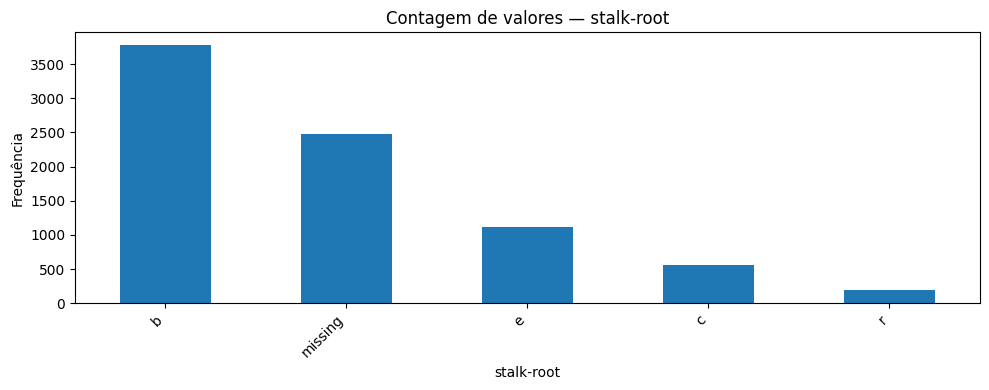

In [28]:
plot_contagem_categorica(df, "stalk-root")

## 2.2 Análise visual — interpretação

[INSERIR INTERPRETAÇÃO DOS GRÁFICOS]

A interpretação deve evitar apenas descrever o óbvio. Procure responder:

- Há concentração de valores?
- Há valores extremos?
- Há categorias muito raras?
- Há desbalanceamento?
- Os padrões observados afetam a tarefa de mineração?
- Alguma visualização sugere risco associado às diretrizes escolhidas?

> Não invente conclusões. Toda afirmação empírica deve estar apoiada em uma tabela, gráfico ou cálculo executado no notebook.


In [26]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
# outliers = detectar_outliers_iqr(df, "[COLUNA_NUMERICA]")
# display(outliers.head())


Contagem de valores ausentes em stalk-root

In [33]:
(df['stalk-root']=='missing').sum()

np.int64(2480)

## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em `stalk-root` | Código de contagem de valores ausentes em stalk-root | MANTER | O missing do `stalk-root` acontece 2480 vezes  |
| Duplicatas | [EVIDÊNCIA] | [DECISÃO] | [JUSTIFICAR] |
| Outliers em [COLUNA] | [EVIDÊNCIA] | [DECISÃO] | [JUSTIFICAR] |
| Categorias raras | [EVIDÊNCIA] | [DECISÃO] | [JUSTIFICAR] |
| Atributos sensíveis ou identificadores | [EVIDÊNCIA] | [DECISÃO] | [JUSTIFICAR] |

### Observação sobre responsabilidade

[EXPLICAR SE ALGUMA DECISÃO DE PREPARAÇÃO TEM IMPLICAÇÕES PARA AS DIRETRIZES ESCOLHIDAS]

Exemplo:

> A remoção de um atributo sensível pode reduzir risco de exposição indevida, mas também pode dificultar a análise de disparidades entre grupos. Essa decisão deve ser justificada com cuidado.


In [7]:
# Exemplo de preparação dos dados
# Esta célula é propositalmente genérica.
# O grupo deve adaptar de acordo com o dataset e a tarefa.

def preparar_dados_basico(
    df: pd.DataFrame,
    colunas_remover=None,
    imputar_numericas=True,
    imputar_categoricas=True
) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas explicitamente marcadas como irrelevantes ou identificadoras
    if colunas_remover is None:
        colunas_remover = [
            # "[INSERIR_COLUNA_IRRELEVANTE]",
        ]

    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    # 3. Exemplo de tratamento simples de nulos
    # Atenção: imputação deve ser justificada no texto.
    if imputar_numericas:
        for col in df_prep.select_dtypes(include=np.number).columns:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    if imputar_categoricas:
        for col in df_prep.select_dtypes(include=["object", "category"]).columns:
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_basico(df, colunas_remover=["id"])
# display(df_prep.head())


## 2.4 Justificativa da preparação dos dados

Explique:

- quais colunas foram removidas e por quê;
- como valores ausentes foram tratados;
- como variáveis categóricas foram tratadas;
- se houve normalização, discretização ou codificação;
- se houve remoção de outliers;
- quais riscos essas decisões introduzem;
- como essas decisões se relacionam às diretrizes escolhidas.

> A preparação dos dados não deve ser apenas uma sequência de comandos. Toda decisão relevante precisa de justificativa técnica.

Removemos a coluna 'classe' que indica se o cogumelo é comestível ou não.<br>
Não tratamos valores ausentes pois o dataset não contem eles.<br>
Mantemos as variáveis categóricas com o valor sendo o label (por exemplo, x, t, c, etc) porque é uma tarefa de pattern mining, e não é necessário fazer técnicas como  OneHotEncoding, OrdinalEncoding etc. <br>
Não foi necessário normalizar ou discretizar, pois só temos variáveis categóricas. <br>
Não foi necessário a remoção de outliers. <br>
Sobre os riscos, continuamos com os mesmos riscos do Dataset original (que foram descritos na seção 1)<br>


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** [EXEMPLO: propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini 
**Data de acesso:** 02/05/2026  
**Link da conversa:** https://gemini.google.com/share/4b4163981a9b

#### Prompt principal — baseline

```text
Tenho um dataset com as seguintes colunas: ["classe","cap-shape","cap-surface","cap-color","bruises","odor","gill-attachment","gill-spacing","gill-size","gill-color","stalk-shape","stalk-root","stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring","stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type","spore-print-color","population","habitat"].

A tarefa de mineração é:

- **Contexto:**
A identificação correta de espécies fúngicas é uma questão de segurança biológica. Com milhares de espécies catalogadas, a diferenciação entre cogumelos comestíveis e venenosos baseada apenas em observação superficial é complexa e arriscada. A mineração de dados surge como uma ferramenta vital para automatizar o cruzamento de múltiplas características físicas, revelando padrões frequentes que possam aumentar a segurança humana nos consumos.

- **Problema:**
O foco deste trabalho é a mineração de regras de associação. Queremos extrair padrões de co-ocorrência onde o consequente de interesse seja a classe do cogumelo (ex: $\{odor: fétido, habitat: gramado\} \rightarrow \{classe: venenoso\}$). Para isso, vamos tratar o dataset como uma base transacional, onde cada cogumelo é uma lista de atributos. O desafio é encontrar regras com alto Suporte, Confiança e Lift que descrevam com precisão os grupos de cogumelos venenosos e comestíveis, permitindo contrastar quais sinais físicos são os melhores indicadores de toxicidade..


Sugira uma estratégia de Data Understanding e Data Preparation para preparar
os dados para essa tarefa.
```

#### Síntese da resposta da LLM

```text
1. Data Understanding (Entendimento dos Dados)
Nesta fase, o foco é identificar a qualidade dos atributos e como eles se distribuem em relação às classes poisonous (venenoso) e edible (comestível).

- Análise de Desbalanceamento: Verifique a proporção entre cogumelos venenosos e comestíveis. Se a base for muito desbalanceada, o Suporte das regras para a classe minoritária será naturalmente baixo, o que pode exigir ajustes nos limiares do algoritmo.
- Cardinalidade dos Atributos: Identifique quantos valores únicos existem por coluna (ex: cap-color pode ter 10 cores, enquanto bruises tem apenas 2). Atributos com altíssima cardinalidade podem fragmentar demais os dados, dificultando a geração de regras com suporte relevante.
- Identificação de Valores Ausentes: No dataset clássico de cogumelos (UCI), a coluna stalk-root costuma apresentar o valor ?. É crucial decidir se esse "desconhecido" será tratado como uma categoria própria ou se as instâncias serão removidas.
- Verificação de Constantes: Procure por colunas com variância zero. Por exemplo, se veil-type tiver o mesmo valor para todos os registros, ela não possui poder discriminatório e deve ser descartada.

2. Data Preparation (Preparação dos Dados)
Para o algoritmo de associação (como Apriori ou FP-Growth), os dados precisam ser tratados como um conjunto de itens.

A. Limpeza e Seleção
- Remoção de Atributos Irrelevantes: Elimine colunas que não agregam informação (como o já mencionado veil-type).
- Tratamento do "stalk-root": Como se trata de segurança biológica, recomendo manter o valor ? renomeando-o para unknown. Remover as linhas poderia eliminar padrões importantes de outras características físicas presentes nesses cogumelos.

B. Transformação para Formato Transacional
- Regras de associação não entendem "colunas", apenas "itens". Você deve transformar o dataset para que cada valor seja precedido pelo nome da coluna, evitando confusões (ex: a cor "brown" pode aparecer no chapéu e no caule).
- Prefixação: Transforme os valores em pares coluna=valor.

Exemplo: cap-shape: convex vira o item cap-shape_convex.
- One-Hot Encoding vs. Listas: * Se usar bibliotecas como MLxtend, transforme o dataframe em uma matriz booleana (One-Hot).
- Se usar abordagens puramente transacionais, converta cada linha em uma lista de strings: ['classe_venenoso', 'odor_fétido', 'habitat_gramado'].

C. Engenharia de Itens (Opcional)
- Agrupamento de Categorias: Se houver cores muito semelhantes com pouquíssimas ocorrências, considere agrupá-las (ex: tons de vermelho e laranja como warm-colors) para aumentar o suporte das regras, desde que isso não comprometa a precisão biológica.

3. Estratégia de Mineração Direcionada
Como o interesse é o consequente ser a classe, você deve configurar o filtro pós-processamento:

- Filtro de Consequente: Após gerar as regras, filtre apenas aquelas onde o consequent seja {classe: venenoso} ou {classe: comestível}.
- Métrica de Lift: Priorize regras com Lift > 1. Isso indica que a presença das características físicas (antecedente) realmente aumenta a probabilidade de ocorrência daquela classe, em vez de ser apenas uma coincidência estatística.
- Busca por "Red Flags": Foque em regras de alta Confiança (próxima de 100%) para a classe venenosa. Na segurança biológica, um falso negativo (dizer que é comestível sendo venenoso) é muito mais grave que um falso positivo.
```

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — guiado

```text
[INSERIR PROMPT GUIADO]

Exemplo:
Tenho um dataset com as seguintes colunas: [LISTAR COLUNAS].
A tarefa de mineração é [TAREFA].
Sugira uma estratégia de Data Understanding e Data Preparation.

Considere explicitamente as diretrizes:
1. [DIRETRIZ 1]
2. [DIRETRIZ 2]

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis, se houver;
- riscos de viés ou perda de informação;
- decisões que devem ser documentadas;
- transformações necessárias;
- limitações e trade-offs.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo | 
|---|---|---|---|
| Tratamento de nulos | Manter valores ausentes como categoria explícita (ex: "stalk-root_unknown") para preservar padrões potencialmente relevantes, evitando perda de informação ao remover linhas |  | Aceitar |
| Tratamento de outliers | Não aplicável diretamente (dados categóricos); foco em identificar categorias com baixa frequência e opcionalmente agrupá-las (ex: cores raras → "other") para evitar fragmentação do suporte |  | REJEITAR |
| Atributos sensíveis | Não há atributos sensíveis no sentido ético; porém, tratar a variável alvo (classe) separadamente e usá-la apenas como consequente nas regras, evitando vazamento indevido no antecedente |  | ACEITAR |
| Codificação de variáveis | Transformação para formato transacional via prefixação (coluna=valor) + possível One-Hot Encoding para uso com Apriori/FP-Growth |  | ACEITAR |
| Redução de dimensionalidade | Remoção de atributos constantes (ex: "veil-type") e possível agrupamento de categorias raras para aumentar suporte e reduzir sparsidade |  | ACEITAR |
| Justificativa técnica | Estratégia focada em maximizar suporte e interpretabilidade das regras, evitando perda de informação (nulos) e eliminando ruído (atributos constantes). A transformação transacional é essencial para algoritmos de associação e a prefixação evita ambiguidade semântica entre atributos |  | ACEITAR |
| Riscos e limitações | Manter "unknown" pode introduzir padrões espúrios; agrupamento excessivo pode reduzir precisão biológica; regras podem ser enviesadas por desbalanceamento de classes; risco de gerar regras óbvias ou tautológicas sem filtragem adequada (ex: lift ≤ 1) |  |  ACEITAR |

### Análise crítica

A LLM sugeriu usar one hot encoding para uso com os algorítmos Apriori/FP-Growth, no entanto, é uma decisão que já foi tomada no notebook na parte de modelagem.
A remoção de atributos constantes foi aceita para diminuir o custo de execução do algorítmo.
Não é uma boa ideia tratar outliers (classes fragmentadas) juntando vários valores em um só porque nosso foco é em ter características precisas para um guia de saúde publica. Agrupar pode nos fazer perder relações semânticas.

-----
Pessoal, analisem se ficou claro?
A análise deve deixar claro:

- o que a LLM sugeriu corretamente;
- o que estava incompleto;
- o que estava tecnicamente errado;
- o que foi aceito;
- o que foi rejeitado;
- o que foi corrigido pelo grupo.


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** [EXEMPLO: propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini
**Data de acesso:** 02/05/2026
**Link da conversa:** https://gemini.google.com/share/8f9c6f94a9b0

#### Prompt principal — baseline

```text
Com base no dataset Mushroom (https://archive.ics.uci.edu/dataset/73/mushroom) e na tarefa:
- **Contexto:**
A identificação correta de espécies fúngicas é uma questão de segurança biológica. Com milhares de espécies catalogadas, a diferenciação entre cogumelos comestíveis e venenosos baseada apenas em observação superficial é complexa e arriscada. A mineração de dados surge como uma ferramenta vital para automatizar o cruzamento de múltiplas características físicas, revelando padrões frequentes que possam aumentar a segurança humana nos consumos.

- **Problema:**
O foco deste trabalho é a mineração de regras de associação. Queremos extrair padrões de co-ocorrência onde o consequente de interesse seja a classe do cogumelo (ex: $\{odor: fétido, habitat: gramado\} \rightarrow \{classe: venenoso\}$). Para isso, vamos tratar o dataset como uma base transacional, onde cada cogumelo é uma lista de atributos. O desafio é encontrar regras com alto Suporte, Confiança e Lift que descrevam com precisão os grupos de cogumelos venenosos e comestíveis, permitindo contrastar quais sinais físicos são os melhores indicadores de toxicidade.

proponha uma estratégia de modelagem.
Indique algoritmos, parâmetros iniciais, métricas de avaliação e como comparar resultados.
```

#### Síntese da resposta da LLM

```text
### 1. Pré-processamento e Transformação
O dataset Mushroom contém 22 atributos categóricos. Para a mineração de regras de associação, o primeiro passo é a preparação dos dados:

* **Tratamento de Dados Ausentes:** O atributo `stalk-root` possui valores faltantes (marcados como `?`). Recomenda-se tratar o `?` como uma categoria própria ("unknown") ou remover a coluna caso a correlação seja baixa, para evitar viés.
* **Codificação Transacional (Binarização):** Algoritmos como Apriori exigem que os dados estejam em formato binário (One-Hot Encoding). Cada par `atributo=valor` (ex: `odor=pungent`) torna-se um item booleano na transação.
* **Inclusão da Classe:** A classe (`edible` ou `poisonous`) deve ser tratada como um item comum para compor as regras.
---
### 2. Escolha do Algoritmo
Propõe-se a utilização do **FP-Growth (Frequent Pattern Growth)**.

* **Justificativa:** Diferente do Apriori, o FP-Growth não gera candidatos de forma exaustiva. Ele utiliza uma estrutura de árvore (FP-tree) para comprimir o dataset, sendo significativamente mais rápido e eficiente em memória para bases com muitos atributos e transações como a de cogumelos.
---
### 3. Parâmetros Iniciais Sugeridos
Para encontrar regras que sejam tanto frequentes quanto confiáveis, sugere-se iniciar com os seguintes limiares:

* **Suporte Mínimo ($min\_support$): 0.1 (10%)**
    * Cogumelos venenosos ou comestíveis costumam compartilhar características em blocos grandes. Um suporte de 10% permite capturar padrões que ocorrem em pelo menos ~812 amostras.
* **Confiança Mínima ($min\_threshold$): 0.9 (90%)**
    * Como se trata de uma questão de segurança biológica, buscamos regras com altíssima precisão. Regras com confiança inferior a 90% são arriscadas para este contexto.
* **Comprimento Máximo da Regra:** Limitar a 3 ou 4 itens no antecedente para garantir que a regra seja interpretável por humanos.
---
### 4. Métricas de Avaliação
Além do Suporte e Confiança, as seguintes métricas são fundamentais:

1.  **Lift:** Mede o quanto a presença do antecedente aumenta a probabilidade do consequente, comparado ao acaso.
    * $Lift > 1$: Indica uma associação positiva forte.
    * $Lift \approx 1$: Indica independência.
2.  **Conviction:** Avalia a dependência lógica. Um valor alto de *conviction* indica que o consequente depende fortemente do antecedente.
3.  **Suporte da Classe:** É vital monitorar o suporte específico para a classe `poisonous` para garantir que padrões de toxicidade raros, mas letais, não sejam descartados.
---
### 5. Estratégia de Filtragem e Contraste
O diferencial desta modelagem será o **Post-Processing (Pós-processamento)**:

* **Filtragem por Consequente:** Filtrar o conjunto total de regras geradas para manter apenas aquelas onde o *Consequente* seja `{class: poisonous}` ou `{class: edible}`.
* **Análise de Regras de Exceção:** Identificar casos onde atributos comuns a cogumelos comestíveis aparecem em venenosos (regras com alta confiança para veneno, mas que desafiam a intuição comum).
* **Remoção de Redundância:** Se a regra $\{odor: fétido\} \rightarrow \{classe: v\}$ possui a mesma confiança que $\{odor: fétido, habitat: grama\} \rightarrow \{classe: v\}$, a regra mais simples deve ser preferida.
---
### 6. Como Comparar os Resultados
A comparação deve ser feita através de dois prismas:

1.  **Capacidade de Cobertura:** Qual percentual do total de cogumelos venenosos é "coberto" pelas 5 principais regras encontradas? Uma boa estratégia deve cobrir quase 100% dos casos venenosos com poucas regras.
2.  **Poder Discriminatório (Sinais Físicos):** Comparar os maiores *Lifts* de cada classe.
    * *Exemplo:* Se o atributo `odor` aparece consistentemente com Lift > 5 em regras de venenosos, ele é um indicador mais forte que `cap-color`.
3.  **Robustez:** Testar se as regras geradas em 70% da base (treino) mantêm o mesmo nível de Confiança e Lift nos 30% restantes (teste/validação).
```

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** [INSERIR MODELO]  
**Data de acesso:** [INSERIR DATA]  
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — guiado

```text
[INSERIR PROMPT GUIADO]

Exemplo:
Com base no dataset [NOME] e na tarefa [TAREFA], proponha uma estratégia de modelagem.

Considere explicitamente as diretrizes:
1. [DIRETRIZ 1]
2. [DIRETRIZ 2]

Na resposta, indique:
- algoritmos adequados;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.
```

#### Síntese da resposta da LLM

[INSERIR SÍNTESE]


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | FP-Growth para mineração de padrões frequentes |  |  | |
| Parâmetros sugeridos | min_support = 0.1 (10%); min_confidence = 0.9 (90%); limite de 3–4 itens no antecedente |  |  |  |
| Métricas sugeridas | Suporte, Confiança, Lift (associação), Conviction (dependência lógica), suporte da classe |  |  |  |
| Preparação exigida | Tratamento de valores faltantes (ex: "unknown"); One-Hot Encoding (binarização); inclusão da classe como item |  |  |  |
| Interpretabilidade | Regras curtas (até 3–4 itens); remoção de redundância; foco em regras explicáveis (ex: odor → classe) |  |  |  |
| Custo computacional | Reduzido/moderado devido ao uso de FP-Growth (estrutura FP-tree evita explosão combinatória) |  |  |  |
| Riscos ou limitações | Possível perda de padrões raros (baixo suporte); viés por dados faltantes; dependência de thresholds; risco de regras espúrias |  |  |  |
| Aderência às diretrizes | Alinhado com mineração de regras de associação, foco em segurança, explicabilidade e validação (treino/teste) |  |  |  |
### Síntese

[INSERIR ANÁLISE COMPARATIVA]

A comparação deve destacar evidências, não impressões vagas.


## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [14]:
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.

def gerar_transacoes_de_coluna(df: pd.DataFrame, separador: str = ",") -> list:
    # Gera uma lista de transações a partir de uma coluna textual.
    # Exemplo: "leite, pão, manteiga" -> ["leite", "pão", "manteiga"]
    transacoes_venenoso, transacoes_comestivel = [], []

    for _,linha in df.iterrows():
        transacao=[]
        for coluna, valor in linha.items():
            if coluna == 'classe':
                continue
            item = f"{coluna}={valor}" # Tive que colocar a chave antes porque poderiamos ter varios valores iguais em colunas diferentes
            transacao.append(item)
        if len(transacao) > 0:
            if linha['classe'] == 'p':
                transacoes_venenoso.append(transacao)
            else:
                transacoes_comestivel.append(transacao)

    
    return transacoes_venenoso, transacoes_comestivel

# Exemplo de uso:
transacoes_venenoso, transacoes_comestivel = gerar_transacoes_de_coluna(df_prep)
print(f"Número de transações venenosas: {len(transacoes_venenoso)}")
print(f"Número de transações comestíveis: {len(transacoes_comestivel)}")


Número de transações venenosas: 3916
Número de transações comestíveis: 4208


In [10]:
# execute se nao tiver instalado mlxtend
%pip install mlxtend

^C
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Exemplo de execução de Apriori e FP-Growth com mlxtend
# Esta célula é semi-funcional e depende da instalação da biblioteca mlxtend.
# O grupo deve ajustar suporte, confiança e métrica conforme o problema.

def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada.")
        print("Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(
        df_transacoes,
        min_support=min_support,
        use_colnames=True,
        max_len=5
    )
    regras_fpgrowth = association_rules(
        itemsets_fpgrowth,
        metric="confidence",
        min_threshold=min_confidence
    )
    tempo_fpgrowth = time.time() - inicio

    resultados = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo": tempo_fpgrowth
    }

    return resultados

# Exemplo de uso:
resultados = {}
resultados['venenoso'] = executar_padroes_frequentes(
    transacoes_venenoso,
    min_support=0.1,
    min_confidence=0.9
)
resultados['comestivel'] = executar_padroes_frequentes(
    transacoes_comestivel,
    min_support=0.1,
    min_confidence=0.9
)


In [13]:
# Resumo dos resultados de mineração de padrões frequentes.
# Esta célula não inventa resultados; ela apenas resume o que foi executado.

def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for classe, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "classe": classe,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
resumo_modelagem = resumir_resultados_padroes(resultados)
display(resumo_modelagem)


,classe,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio
0,venenoso,26995,94505,1.4751,0.100102,1.0,0.993894,1.696838
1,comestivel,20410,62151,1.3670,0.100760,1.0,0.982434,1.469286


In [ ]:
# Exemplo de variação de parâmetros
# Útil para verificar se os resultados são sensíveis às escolhas de suporte e confiança.

def testar_parametros_padroes(transacoes, suportes, confiancas):
    linhas = []

    for sup in suportes:
        for conf in confiancas:
            resultados = executar_padroes_frequentes(
                transacoes,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support"] = sup
                resumo["min_confidence"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# Exemplo de uso:
grade_resultados_venenoso = testar_parametros_padroes(
    transacoes_venenoso,
    suportes=[0.01, 0.03, 0.05],
    confiancas=[0.5, 0.6, 0.7]
)
display(grade_resultados_venenoso)

grade_resultados_comestivel = testar_parametros_padroes(
    transacoes_comestivel,
    suportes=[0.01, 0.03, 0.05],
    confiancas=[0.5, 0.6, 0.7]
)
display(grade_resultados_comestivel)


## 3.6 Resultados preliminares da modelagem

[INSERIR RESULTADOS OBTIDOS APÓS EXECUÇÃO DO CÓDIGO]

Inclua tabelas e comentários sobre os resultados relevantes para a tarefa:

### Se a tarefa for padrões frequentes

- número de padrões encontrados;
- número de regras geradas;
- suporte, confiança e lift;
- tempo de execução;
- redundância e interpretabilidade das regras.


### Atenção

Não conclua que um algoritmo é “melhor” apenas por uma métrica isolada.

Uma comparação adequada deve considerar:

- qualidade da solução;
- interpretabilidade;
- custo computacional;
- estabilidade;
- adequação ao problema;
- relação com as diretrizes escolhidas.


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| [DIRETRIZ 1] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |
| [DIRETRIZ 2] | [PREENCHER] | [PREENCHER] | [SIM/NÃO/PARCIALMENTE] | [JUSTIFICAR] |

### Discussão

[INSERIR DISCUSSÃO]

A resposta deve ser específica. Exemplos de boa análise:

- “A Trilha B sugeriu registrar parâmetros e versões dos experimentos, o que melhora rastreabilidade.”
- “A Trilha B sugeriu avaliar desempenho por subgrupos, o que é pertinente à diretriz de justiça e viés.”
- “A Trilha B recomendou um algoritmo mais interpretável, mas com possível perda de desempenho.”
- “Apesar de mencionar privacidade, a Trilha B não propôs nenhuma alteração concreta no pipeline.”

Evite frases vagas como:

- “A resposta guiada foi mais responsável.”
- “A LLM considerou melhor as diretrizes.”
- “O resultado foi mais ético.”


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |
| [SUGESTÃO 3] | Guiada | [ACEITA/REJEITADA/CORRIGIDA] | [JUSTIFICAR] |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |
| [ERRO/OMISSÃO] | [A/B] | [EXPLICAR] | [EXPLICAR] |

### Comentário crítico

[INSERIR COMENTÁRIO SOBRE A QUALIDADE DAS RESPOSTAS DA LLM]


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Correção técnica | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Clareza das justificativas | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da modelagem | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Qualidade da avaliação | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Riscos não tratados | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão comparativa

[INSERIR CONCLUSÃO]

A conclusão deve indicar se a explicitação das diretrizes:

- produziu mudanças concretas;
- produziu apenas mudanças superficiais;
- não produziu diferença relevante;
- introduziu novos trade-offs;
- ajudou a identificar limitações ou riscos;
- levou o grupo a alterar decisões técnicas.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Privacidade × utilidade dos dados | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Custo computacional × qualidade da solução | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Simplicidade × completude da análise | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |
| Justiça/viés × disponibilidade de atributos | [INSERIR EVIDÊNCIA] | [INSERIR DECISÃO] |

### Discussão

[INSERIR DISCUSSÃO SOBRE OS TRADE-OFFS]

Nem todo trade-off estará presente em todo trabalho. O grupo deve discutir apenas os que forem pertinentes ao dataset e à tarefa.


## 4.5 Considerações finais da Fase 2

[INSERIR CONSIDERAÇÕES FINAIS]

A conclusão da Fase 2 deve responder:

1. A LLM ajudou em quais partes do trabalho?
2. Em quais partes a LLM errou ou foi superficial?
3. A Trilha B foi de fato diferente da Trilha A?
4. As diretrizes escolhidas tiveram efeito concreto?
5. Quais sugestões serão levadas para a Fase 3?
6. Quais sugestões serão descartadas?
7. O que ainda precisa ser implementado ou corrigido na versão final?

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

[INSERIR REFERÊNCIAS USADAS PELO GRUPO]

Exemplos de referências possíveis:

- documentação do dataset;
- materiais da disciplina;
- documentação das bibliotecas usadas;
- referências sobre CRISP-DM;
- referências sobre IA responsável;
- referências sobre algoritmos aplicados.

> As referências devem apoiar decisões técnicas e metodológicas. Não use referências apenas de forma decorativa.


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [ ]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)
